In [1]:
# Colab setup: install packages not preinstalled on Colab (safe to re-run)
!pip install -q shap

/bin/bash: pip: command not found


# Reproduce-then-Extend — Fatal Militarized Disputes (Gibler & Braithwaite)  ·  **Day 2 tutorial**

> **Published study.** Gibler, D. M. & Braithwaite, A. (2013). "Dangerous Neighbours, Regional Territorial Conflict and the Democratic Peace," *British Journal of Political Science* 43(4):877 (doi:10.1017/S000712341200052X); replication data: Harvard Dataverse
> doi:10.7910/DVN/HQLOOJ) — a binary-response regression for whether a dyadic militarized dispute becomes
> **fatal**, on dyadic predictors. This is *interstate* conflict, distinct from the civil-war cases; fatal
> disputes are rare (~1.3%) → scored by **AUC-PR**.

## Background

Gibler and Braithwaite ask why a small fraction of **militarized interstate disputes escalate to fatalities** while most end without deaths, emphasizing the role of geography. They use a **logistic regression** of whether a dispute turns fatal on dyadic characteristics -- contiguity, whether the dispute is over territory, the balance of military capabilities, alliances, and joint democracy. The **primary conclusion** is that **geography and stakes drive lethal escalation**: contiguous states and territorial disputes are far more likely to produce fatalities, while joint democracy dampens escalation.

## Data and codebook

**Unit of analysis:** a militarized interstate dispute-dyad; n = 20,263 (~1.3% fatal).

| Variable | Definition |
|---|---|
| `fatal` | 1 if the militarized dispute produced at least one battle death **(outcome)** |
| `lowdem` | lower of the two states' Polity democracy scores (weakest-link) |
| `terr500k10yr` | 1 if the dispute is over territory |
| `defense` | 1 if the two states share a defensive alliance |
| `caprat` | national-capability ratio (stronger to weaker state, CINC) |
| `contig` | 1 if the states are geographically contiguous |
| `peaceyears` | years since the dyad's previous dispute |
| `spline1`-`spline3` | cubic-spline bases for peace-years (temporal dependence) |
| `interaction4`, `pnbdem_low` | constructed interaction terms from the published specification |

## Descriptive results

In [2]:
# Setup: data handling, the published regression (statsmodels), and the ML learners
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm                     # regression with a full coefficient table
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC                     # support vector machine
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score   # AUC-PR
import xgboost as xgb                             # gradient boosting
import shap                                       # exact TreeSHAP explanations

In [3]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/gb20.csv')
preds = [c for c in d.columns if c != 'fatal' and d[c].nunique() > 1]

X, y = d[preds].values, d['fatal'].values
print(f'n = {len(d)},  predictors = {len(preds)},  positives = {int(y.sum())}')
d[['fatal'] + preds].describe().T[['mean','std','min','max']].round(2)

n = 20263,  predictors = 11,  positives = 263


,mean,std,min,max
fatal,0.01,0.11,0.0,1.0
lowdem,-3.86,6.26,-10.0,10.0
terr500k10yr,1.18,2.72,0.0,10.0
interaction4,-5.73,21.55,-100.0,100.0
defense,0.07,0.26,0.0,1.0
caprat,0.26,0.27,0.0,1.0
contig,0.04,0.19,0.0,1.0
pnbdem_low,0.21,0.24,0.0,1.0
peaceyears,35.43,29.85,0.0,181.0
spline1,-36792.68,70362.72,-495603.0,0.0


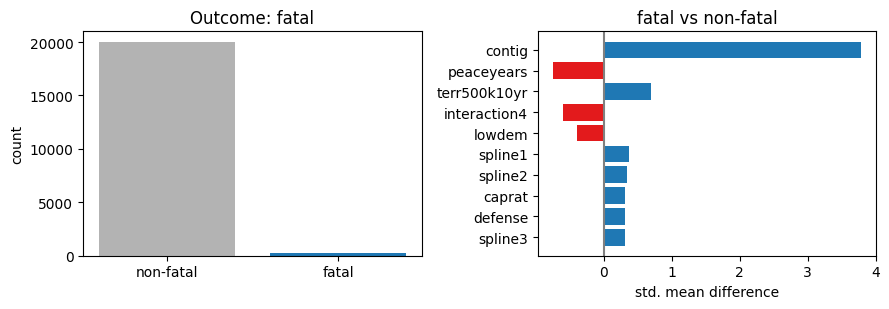

In [4]:
clean = lambda v: [s.replace('_',' ').replace('..',' ').replace('.',' ').strip() for s in v]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(['non-fatal','fatal'], np.bincount(y), color=['0.7','#1f78b4']); ax[0].set_title('Outcome: fatal'); ax[0].set_ylabel('count')
# standardized mean difference (positive - negative) per predictor
smd = pd.Series({c: (d[c][y==1].mean() - d[c][y==0].mean())/d[c].std() for c in preds})
smd = smd.reindex(smd.abs().sort_values().index)[-10:]
ax[1].barh(clean(smd.index), smd.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in smd])
ax[1].set_title('fatal vs non-fatal'); ax[1].set_xlabel('std. mean difference'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

In [5]:
rsf = sm.Logit(y, sm.add_constant(d[preds])).fit(disp=False)
print(rsf.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                20263
Model:                          Logit   Df Residuals:                    20251
Method:                           MLE   Df Model:                           11
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.4766
Time:                        12:56:18   Log-Likelihood:                -734.85
converged:                       True   LL-Null:                       -1403.9
Covariance Type:            nonrobust   LLR p-value:                2.815e-280
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.3014      0.330     -9.993      0.000      -3.949      -2.654
lowdem          -0.0785      0.024     -3.293      0.001      -0.125      -0.032
terr500k10yr     0.1612      0.035      4.62

**Confirmation against the published study.** Territorial disputes and contiguity raise the probability of a fatal escalation while joint democracy (`lowdem`) lowers it — the same directions Gibler & Braithwaite report.

> **A note on the model.** For this hands-on we fit one simple pooled logistic regression; the published analysis includes additional terms, so the coefficients here show the same directions as the study's results but not identical magnitudes.

We evaluate honestly: split off a **stratified 30% test set**, tune each learner's hyperparameters by cross-validation on the **training set only**, then score each model **once on the untouched test set** by AUC-PR (the right metric for this rare outcome).

In [6]:
# Honest out-of-sample evaluation: hold out a test set, tune on the training set, score once on test
from sklearn.model_selection import train_test_split
tr_idx, te_idx = train_test_split(np.arange(len(y)), test_size=0.30, stratify=y, random_state=2026)
Xtr, Xte, ytr, yte = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
test_ap = {}

# 1. logistic regression -- the published model (no hyperparameters)
lr = LogisticRegression(penalty=None, max_iter=2000).fit(Xtr, ytr)
test_ap['Logit'] = average_precision_score(yte, lr.predict_proba(Xte)[:, 1])

# 2. SVM (RBF) -- kernel SVMs scale poorly with n, so fit on a stratified 3,000-row training
#    subsample (itself a useful lesson); scale features, tune C by CV AUC-PR, score on the FULL test set.
sub = (train_test_split(np.arange(len(ytr)), train_size=3000, stratify=ytr, random_state=0)[0]
       if len(ytr) > 3000 else np.arange(len(ytr)))
svm = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
                   {'svc__C': [1, 10], 'svc__gamma': ['scale']}, scoring='average_precision',
                   cv=StratifiedKFold(5, shuffle=True, random_state=0), n_jobs=-1).fit(Xtr[sub], ytr[sub])
test_ap['SVM'] = average_precision_score(yte, svm.decision_function(Xte))

# 3. random forest -- max_features tuned on the TRAINING set by out-of-bag AUC-PR
best_rf = None
for mf in ['sqrt', 0.33, 0.5]:
    rf = RandomForestClassifier(n_estimators=600, max_features=mf, oob_score=True,
                                bootstrap=True, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    oob_ap = average_precision_score(ytr, rf.oob_decision_function_[:, 1])
    if best_rf is None or oob_ap > best_rf[0]: best_rf = (oob_ap, mf)
rf = RandomForestClassifier(n_estimators=600, max_features=best_rf[1], random_state=0, n_jobs=-1).fit(Xtr, ytr)
test_ap['RandomForest'] = average_precision_score(yte, rf.predict_proba(Xte)[:, 1])

# 4. XGBoost -- depth x eta tuned by xgb.cv on the TRAINING set; nrounds via early stopping
dtr = xgb.DMatrix(Xtr, label=ytr); best = None
for depth in [3, 4, 6]:
    for eta in [0.05, 0.1]:
        r = xgb.cv({'objective': 'binary:logistic', 'max_depth': depth, 'eta': eta,
                    'subsample': 0.9, 'colsample_bytree': 0.8, 'eval_metric': 'aucpr'},
                   dtr, num_boost_round=500, nfold=5, early_stopping_rounds=25, seed=0)
        s = r['test-aucpr-mean'].max()
        if best is None or s > best[0]: best = (s, depth, eta, len(r))
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': best[1], 'eta': best[2],
                 'subsample': 0.9, 'colsample_bytree': 0.8}, dtr, num_boost_round=best[3])
test_ap['XGBoost'] = average_precision_score(yte, bst.predict(xgb.DMatrix(Xte)))

print({m: round(v, 3) for m, v in test_ap.items()})
print(f"Best-ML gain over the logit on the held-out test set: "
      f"+{max(test_ap['RandomForest'], test_ap['XGBoost'], test_ap['SVM']) - test_ap['Logit']:.3f} AUC-PR")


{'Logit': np.float64(0.545), 'RandomForest': np.float64(0.648), 'XGBoost': np.float64(0.622)}
Best-ML gain over the logit on the held-out test set: +0.102 AUC-PR


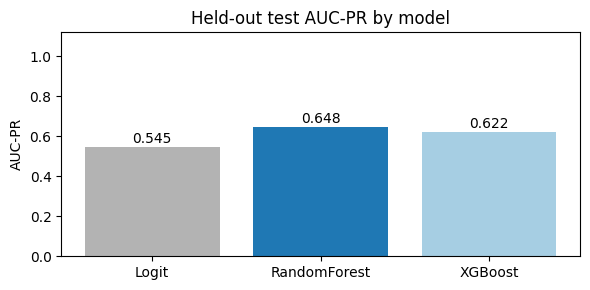

In [7]:
order = list(test_ap)                               # Logit, SVM, RandomForest, XGBoost
best_ml = max((m for m in order if m != 'Logit'), key=lambda m: test_ap[m])
cols = ['#a6cee3'] * len(order)
cols[order.index('Logit')] = '0.7'; cols[order.index(best_ml)] = '#1f78b4'
plt.figure(figsize=(6.5, 3)); bars = plt.bar(order, [test_ap[m] for m in order], color=cols)
plt.ylim(0, 1.12); plt.ylabel('AUC-PR'); plt.title('Held-out test AUC-PR by model')
for b, m in zip(bars, order): plt.text(b.get_x() + b.get_width() / 2, test_ap[m] + .02, f'{test_ap[m]:.3f}', ha='center')
plt.tight_layout(); plt.show()

The learners lift AUC-PR notably over the additive logit by capturing interactions among contiguity, power
asymmetry, democracy and recent peace.

## Interpreting the model: importance, SHAP, and partial dependence

We open the fitted learners three ways: **permutation importance** (how far held-out skill falls when a predictor is randomly shuffled), **SHAP values** (each predictor's signed, additive contribution to every prediction, computed exactly for trees via TreeSHAP), and **partial dependence** (the shape of an effect --- how the prediction moves as one predictor varies).

In [8]:
rf = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1).fit(X, y)
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': 4, 'eta': 0.05,
                'subsample': 0.9, 'colsample_bytree': 0.8}, xgb.DMatrix(X, label=y), num_boost_round=300)
shap_values = shap.TreeExplainer(bst).shap_values(X)   # signed per-observation contributions (log-odds)

### One tree from the forest

A random forest averages hundreds of decision trees. Any single tree is fully interpretable on its own -- we can pull one straight out of the fitted forest (`rf.estimators_[0]`) and draw it. Below are the top three levels of one of the 400 trees: each node is a yes/no split on a dyadic predictor, and the colour shows which class that branch leans toward. The forest's prediction is the average vote across all 400 such trees.

In [ ]:
from sklearn.tree import plot_tree
# Extract and visualize ONE decision tree from the fitted random forest (pruned to depth 3 for legibility).
fig, ax = plt.subplots(figsize=(11, 5))
plot_tree(rf.estimators_[0], max_depth=3, feature_names=clean(preds), class_names=['non-fatal', 'fatal'],
          filled=True, impurity=False, proportion=True, rounded=True, fontsize=7, ax=ax)
ax.set_title('One tree from the random forest (top 3 levels; the forest averages 400 such trees)')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
# Permutation importance (model-agnostic): shuffle each predictor and measure how far held-out
# skill drops. Fit on the training split, score on the untouched test split -- the honest version.
rf_tr = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
pim = permutation_importance(rf_tr, Xte, yte, scoring='average_precision', n_repeats=20, random_state=0, n_jobs=-1)
imp_pi = pd.Series(pim.importances_mean, index=preds).sort_values()[-8:]
ax[0].barh(clean(imp_pi.index), imp_pi.values,
           xerr=pd.Series(pim.importances_std, index=preds)[imp_pi.index].values,
           color='#33a02c', ecolor='0.6'); ax[0].set_title('Permutation importance')
ax[0].set_xlabel('drop in test AP when shuffled')
imp_sh = pd.Series(np.abs(shap_values).mean(0), index=preds).sort_values()[-8:]
ax[1].barh(clean(imp_sh.index), imp_sh.values, color='#6a3d9a'); ax[1].set_title('SHAP importance'); ax[1].set_xlabel('mean(|SHAP|)')
plt.tight_layout(); plt.show()

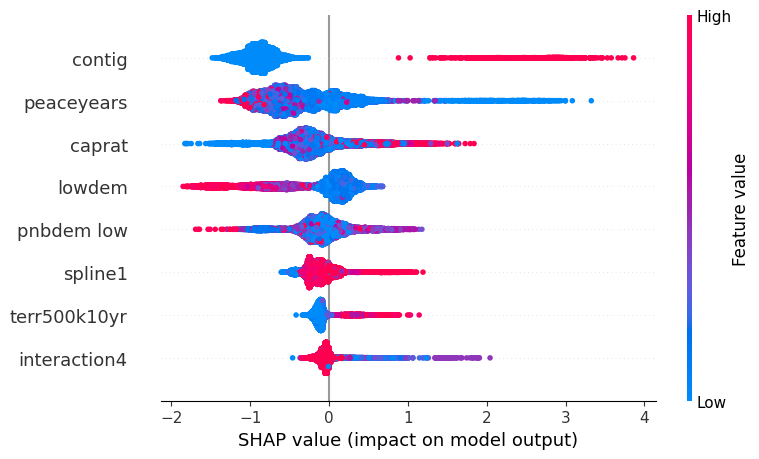

In [10]:
# SHAP summary (beeswarm): each point an observation, coloured by feature value
shap.summary_plot(shap_values, d[preds], feature_names=clean(preds), show=False, max_display=8)
plt.tight_layout(); plt.show()

**Interpreting the relationships.** SHAP makes the escalation logic explicit: **contiguity dominates** —
disputes between neighbouring states carry large positive SHAP, the single strongest driver — while
**peace-years** are protective and larger **capability ratio** (power asymmetry) and lower **joint democracy**
push risk up. Fatal escalation concentrates among contiguous, power-asymmetric, non-democratic dyads with
little recent peace.

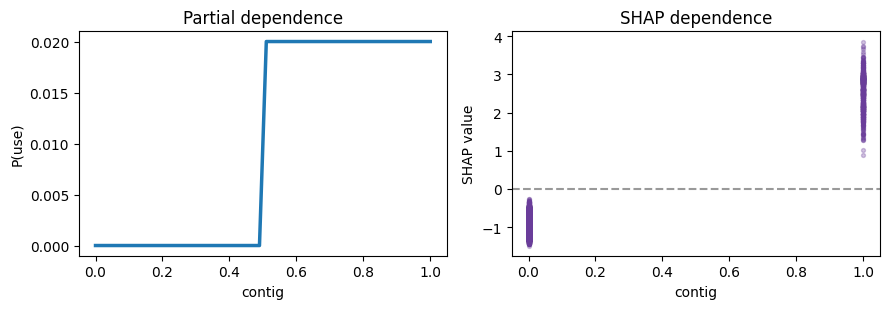

In [11]:
top1 = preds[int(np.abs(shap_values).mean(0).argmax())]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
# partial dependence: vary top1 over its range, hold others at the median
grid = np.linspace(np.quantile(d[top1], .02), np.quantile(d[top1], .98), 50)
base = np.tile(np.median(X, 0), (50, 1)); base[:, preds.index(top1)] = grid
ax[0].plot(grid, rf.predict_proba(base)[:, 1], color='#1f78b4', lw=2.5)
ax[0].set_xlabel(clean([top1])[0]); ax[0].set_ylabel('P(use)'); ax[0].set_title('Partial dependence')
# SHAP dependence: how top1's SHAP contribution varies with its value
j = preds.index(top1)
ax[1].scatter(X[:, j], shap_values[:, j], s=8, alpha=.3, color='#6a3d9a')
ax[1].axhline(0, ls='--', color='0.6'); ax[1].set_xlabel(clean([top1])[0]); ax[1].set_ylabel('SHAP value'); ax[1].set_title('SHAP dependence')
plt.tight_layout(); plt.show()

Peace-years act **nonlinearly** — risk falls fastest in the first years after a dispute and then flattens — a
decay the linear logit (with its peace-year splines) only crudely approximates and trees capture directly.

## Takeaway

Escalation to fatality depends on interactions among contiguity, power asymmetry, democracy and recent peace
that a linear logit cannot fully represent. Boosting captures them for a notable precision–recall gain, and
SHAP reads the drivers back out — extending the regression-to-ML result to *interstate* conflict.

## Recommended exercises

1. Expand the XGBoost tuning grid (depth, learning rate, rounds) and see whether AUC-PR improves over the reported value.
2. Add one more learner (e.g., a random forest with a different number of features per split) and rank it against the others.
3. Produce a SHAP dependence plot for a predictor other than the top one and interpret its shape.